# Paper tables — automatic generation

Builds the three tables in the paper directly from the result JSONs:

1. **In-distribution comparison** (Small + Base sections)
2. **Cross-distribution generalization** — 10-shot system comparison
3. **Ablation** — LoRA → +PiSSA (all layers) across ImageNet vs DINOv3 backbones, on cross-orientation and cross-dataset transfer pairs

Nothing is hard-coded — every number is read from `results/in_distribution/` (in-distribution) or `results/cross_distribution/` (cross-distribution). Parameter counts come from instantiating the model factories.

In [1]:
# ── Setup ─────────────────────────────────────────────────────────
from __future__ import annotations
import json, glob, os, re, sys
from collections import defaultdict
from pathlib import Path
from typing import Iterable, Optional

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

REPO_ROOT = Path.cwd()
assert (REPO_ROOT / "results").is_dir(), f"run from repo root; got {REPO_ROOT}"
sys.path.insert(0, str(REPO_ROOT))

IN_DIST_DIR = REPO_ROOT / "results" / "in_distribution"
# PEFT sweep + resnet/frozen baselines share this dir (distinct prefixes).
CROSS_DIR   = REPO_ROOT / "results" / "cross_distribution"

# Headline cross-dataset transfer pairs (label → (source, target)).
CROSS_PAIRS = {
    "Cross-age":         ("glasgow_young", "glasgow_mature"),
    "Cross-orientation": ("mad_sub12",     "mad_sub3"),
    "Cross-Dataset":     ("glasgow_5",     "mad_5"),
}
ABLATION_PAIR = ("glasgow_5", "mad_5")  # ablation tables use this pair

FT_SEEDS = (0, 1, 2)
EPOCHS, LR_TAG, RANK = 60, "1em4", 8
# ── Metric switch ─────────────────────────────────────────────────
# Every table below reads this. "acc" reproduces the paper's tables;
# "f1" reproduces the macro-F1 companion tables released alongside them
# (Sec. 3.1: macro-F1 was computed for every experiment because walking is
# over-represented after segmentation).
METRIC = "acc"

def _mean_key() -> str:
    return f"mean_{METRIC}"

def _std_key() -> str:
    return f"std_{METRIC}"


In [2]:
# ── Parameter counts (instantiate each factory at n_classes=6) ────
# Silence the timm deprecation banner during model construction.
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from scripts.run_eval import SUPERVISED_REGISTRY
from eval.models.dinov3 import DINOv3Extractor
from eval.models.vit_imagenet import ViTImageNetExtractor

def _count(m):
    tr  = sum(p.numel() for p in m.parameters() if p.requires_grad)
    tot = sum(p.numel() for p in m.parameters())
    return tr, tot

FT_KEYS = [
    "dinov3_vits16_pissa", "dinov3_vitb16_pissa",
    "vit_small_imagenet_lora",
    "vit_small_imagenet_selafd", "vit_base_imagenet_selafd",
    "resnet50", "dinov3_vits16_full_ft",
]
FROZEN_KEYS = [
    ("dinov3_vits16",      lambda: DINOv3Extractor(variant="vits16").model),
    ("vit_small_imagenet", lambda: ViTImageNetExtractor(variant="vits16").model),
    ("dinov3_vitb16",      lambda: DINOv3Extractor(variant="vitb16").model),
    ("vit_base_imagenet",  lambda: ViTImageNetExtractor(variant="vitb16").model),
]

PARAMS: dict[str, tuple[int, int]] = {}
for key in FT_KEYS:
    factory, _ = SUPERVISED_REGISTRY[key]
    PARAMS[key] = _count(factory(6))
for key, ctor in FROZEN_KEYS:
    backbone = ctor()
    PARAMS[key] = (0, sum(p.numel() for p in backbone.parameters()))

# Tidy display.
_rows = [(k, tr, tot, 100*tr/max(tot,1)) for k, (tr, tot) in PARAMS.items()]
_df = pd.DataFrame(_rows, columns=["key", "trainable", "total", "%"]).set_index("key")
_df

/home/keryane/uDoppler_SSL/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 211/211 [00:00<00:00, 12563.68it/s]

2026-09-15 11:31:36.823 | INFO     | eval.models.dinov3_lora:build_dinov3_lora:132 - DINOv3-vits16 PiSSA (r=8, alpha=16, targets=['q_proj', 'k_proj', 'v_proj', 'o_proj', 'up_proj', 'down_proj']): 663,552 trainable / 22,260,096 total params (2.98%)


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 211/211 [00:00<00:00, 7562.86it/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 211/211 [00:00<00:00, 10445.78it/s]

,trainable,total,%
key,,,
dinov3_vits16_pissa,665862,22262406,2.990971
dinov3_vitb16_pissa,1331718,86992134,1.530849
vit_small_imagenet_lora,223494,21889158,1.021026
vit_small_imagenet_selafd,3628806,25294470,14.346242
vit_base_imagenet_selafd,14335494,100134150,14.316289
resnet50,23520326,23520326,100.000000
dinov3_vits16_full_ft,21598854,21598854,100.000000
dinov3_vits16,0,21596544,0.000000
vit_small_imagenet,0,21665664,0.000000


In [3]:
# ── Helpers: load result files and pull metrics ──────────────────
# All readers below return the metric selected by the global METRIC, so the
# same table code renders either the accuracy or the macro-F1 version.
def _supervised(d: dict) -> Optional[tuple[float, float]]:
    sv = d.get("probes", {}).get("supervised")
    return None if not sv else (sv[_mean_key()], sv[_std_key()])

def _linear(d: dict, n_shots: object) -> Optional[float]:
    """Mean metric for the requested shot count from a linear_C1.0 probe.
    Pass n_shots=None for the 'full' entry."""
    lp = d.get("probes", {}).get("linear_C1.0")
    if lp is None:
        return None
    if isinstance(lp, dict):           # cross_eval-style: single point
        return lp.get(METRIC)
    for e in lp:
        if e["n_shots"] == n_shots:
            return e[_mean_key()]
    return None

def _load(path: Path) -> Optional[dict]:
    return json.loads(path.read_text()) if path.exists() else None

def in_dist_ft(key: str, dataset: str) -> Optional[tuple[float, float]]:
    """In-distribution supervised CV metric for a fine-tuned method."""
    d = _load(IN_DIST_DIR / f"{key}_ep{EPOCHS}_lr{LR_TAG}_s42__{dataset}.json")
    return None if d is None else _supervised(d)

def in_dist_frozen(key: str, dataset: str) -> Optional[tuple[float, float]]:
    """In-distribution linear-probe (frozen) result. Prefers the
    deterministic-named file, falls back to the most recent timestamped one."""
    det = IN_DIST_DIR / f"{key}__{dataset}.json"
    if det.exists():
        d = _load(det)
    else:
        d = None
        cand = sorted(IN_DIST_DIR.glob(f"{key}__{dataset}__*.json"))
        if cand:
            d = _load(cand[-1])
    if d is None:
        return None
    lp = d["probes"]["linear_C1.0"]
    return (lp[_mean_key()], lp[_std_key()])


In [4]:
# ── Cross-dataset helpers (PEFT sweep + frozen + ResNet50) ────────
def _peft_seeds(file_glob: str, predicate) -> dict[int, dict]:
    """Collect {seed: per_shot_dict} from peft_sweep files matching the
    glob, keeping only those for which `predicate(sweep_tag)` is True."""
    out: dict[int, dict] = {}
    for fp in CROSS_DIR.glob(file_glob):
        d = json.loads(fp.read_text())
        sw = d.get("sweep", {})
        if not predicate(sw):
            continue
        seed = sw["seed"]
        out[seed] = {e["n_shots"]: e[_mean_key()] for e in d["probes"]["linear_C1.0"]}
    return out

def cross_peft(method: str, targets: str, src: str, tgt: str,
               shot: object) -> Optional[tuple[float, float]]:
    """Aggregate the 3-seed mean/std of METRIC for a PEFT method at one shot level.
    Uses a permissive glob and lets the sweep-tag predicate do the filtering
    (file naming for `lora_in`/`pissa_in` reorders the method tokens, so a
    method-specific glob would miss them)."""
    seeds = _peft_seeds(
        f"vits16_*_s*__{src}__{tgt}.json",
        lambda s: (
            s.get("method") == method
            and s.get("epochs") == EPOCHS
            and s.get("lr") == 1e-4
            and s.get("rank") == RANK
            and s.get("targets") == targets
        ),
    )
    vs = [seeds[s][shot] for s in sorted(seeds) if shot in seeds[s]]
    return (float(np.mean(vs)), float(np.std(vs, ddof=0))) if vs else None

def cross_selafd(src: str, tgt: str, shot: object) -> Optional[tuple[float, float]]:
    seeds = _peft_seeds(
        f"vits16_vit_selafd_lr{LR_TAG}_s*__{src}__{tgt}.json",
        lambda s: s.get("method") == "selafd" and s.get("epochs") == EPOCHS
                  and s.get("lr") == 1e-4,
    )
    vs = [seeds[s][shot] for s in sorted(seeds) if shot in seeds[s]]
    return (float(np.mean(vs)), float(np.std(vs, ddof=0))) if vs else None

def cross_full_ft(src: str, tgt: str, shot: object) -> Optional[tuple[float, float]]:
    """DINOv3 ViT-S, fully fine-tuned (no PEFT) — same backbone as the PiSSA
    row, isolating adaptation strategy from backbone choice (see Table 2)."""
    seeds = _peft_seeds(
        f"vits16_dinov3_full_ft_lr{LR_TAG}_s*__{src}__{tgt}.json",
        lambda s: s.get("method") == "full_ft" and s.get("epochs") == EPOCHS
                  and s.get("lr") == 1e-4,
    )
    vs = [seeds[s][shot] for s in sorted(seeds) if shot in seeds[s]]
    return (float(np.mean(vs)), float(np.std(vs, ddof=0))) if vs else None


def cross_resnet(src: str, tgt: str, shot: object) -> Optional[tuple[float, float]]:
    seeds: dict[int, float] = {}
    for fp in CROSS_DIR.glob(f"resnet50_s*_ft_{src}__{tgt}.json"):
        m = re.match(r"resnet50_s(\d)_ft_", fp.name)
        if not m: continue
        d = json.loads(fp.read_text())
        v = _linear(d, shot)
        if v is not None:
            seeds[int(m.group(1))] = v
    vs = list(seeds.values())
    return (float(np.mean(vs)), float(np.std(vs, ddof=0))) if vs else None

def cross_frozen(backbone_key: str, src: str, tgt: str, shot: object) -> Optional[float]:
    """Read the single deterministic frozen run for a (src, tgt) pair.
    backbone_key is the bare extractor key (e.g. 'dinov3_vits16'); the
    glob template adds the '_frozen_frozen_' that run_cross_few_shot.py uses
    when --freeze is set (model_name has '_frozen' suffix, plus the 'frozen_'
    tag in the display name)."""
    cand = sorted(CROSS_DIR.glob(f"{backbone_key}_frozen_frozen_{src}__{tgt}.json"))
    if not cand:
        return None
    return _linear(json.loads(cand[-1].read_text()), shot)


In [5]:
# ── Display helpers ───────────────────────────────────────────────
def fmt_pair(pair: Optional[tuple[float, float]]) -> str:
    return "—" if pair is None else f"{pair[0]*100:.2f} ({pair[1]*100:.2f})"

def fmt_single(v: Optional[float]) -> str:
    return "—" if v is None else f"{v*100:.2f}"

def fmt_params(trainable: int, total: int) -> tuple[str, str]:
    if trainable == 0:
        return ("~0 M (probe only)", f"{total/1e6:.2f} M")
    if trainable >= 1e6:
        tr_s = f"{trainable/1e6:.2f} M ({100*trainable/total:.2f}%)"
    else:
        tr_s = f"{trainable/1e3:.0f} K ({100*trainable/total:.2f}%)"
    return (tr_s, f"{total/1e6:.2f} M")

## Table 1 — In-distribution comparison

Mean (std) over 5 subject-disjoint StratifiedGroupKFold folds, seed=42, ep=60, lr=1e-4.
FT rows: supervised CV accuracy; frozen rows: linear-probe accuracy on cached features.

In [6]:
# Layout follows the paper: Small section then Base section.
T1_ROWS = [
    # (label, key, kind)  kind ∈ {'ft', 'frozen', 'hdr'}
    ("Small (~22-25M total)", None, "hdr"),
    ("ViT-S ImageNet (frozen)",         "vit_small_imagenet",        "frozen"),
    ("DINOv3-S (frozen)",               "dinov3_vits16",             "frozen"),
    ("ResNet50 (ft)",                   "resnet50",                  "ft"),
    # Same backbone as the PiSSA row below, no PEFT — isolates adaptation
    # strategy from backbone choice (see Table 2's matching row).
    ("DINOv3-S (full FT)",              "dinov3_vits16_full_ft",     "ft"),
    ("SelaFD ViT-S",                    "vit_small_imagenet_selafd", "ft"),
    ("ViT-S + LoRA",                    "vit_small_imagenet_lora",   "ft"),
    ("DINOv3-S + PiSSA (Ours)",         "dinov3_vits16_pissa",       "ft"),
    ("Base (~86-100M total)", None, "hdr"),
    ("ViT-B ImageNet (frozen)",         "vit_base_imagenet",         "frozen"),
    ("DINOv3-B (frozen)",               "dinov3_vitb16",             "frozen"),
    ("SelaFD ViT-B",                    "vit_base_imagenet_selafd",  "ft"),
    ("DINOv3-B + PiSSA (Ours)",         "dinov3_vitb16_pissa",       "ft"),
]

def build_t1() -> pd.DataFrame:
    """Table 1, rendered in whatever the global METRIC is set to."""
    records = []
    for label, key, kind in T1_ROWS:
        if kind == "hdr":
            records.append({"Method": f"*{label}*", "Trainable": "",
                            "Total": "", "Glasgow": "", "MAD": ""})
            continue
        tr_s, tot_s = fmt_params(*PARAMS[key])
        g = in_dist_ft(key, "glasgow") if kind == "ft" else in_dist_frozen(key, "glasgow")
        m = in_dist_ft(key, "mad")     if kind == "ft" else in_dist_frozen(key, "mad")
        records.append({"Method": label, "Trainable": tr_s, "Total": tot_s,
                        "Glasgow": fmt_pair(g), "MAD": fmt_pair(m)})
    return pd.DataFrame(records)

T1 = build_t1()
display(Markdown(T1.to_markdown(index=False)))
T1


| Method                  | Trainable         | Total    | Glasgow      | MAD          |
|:------------------------|:------------------|:---------|:-------------|:-------------|
| *Small (~22-25M total)* |                   |          |              |              |
| ViT-S ImageNet (frozen) | ~0 M (probe only) | 21.67 M  | 87.16 (1.58) | 63.51 (1.24) |
| DINOv3-S (frozen)       | ~0 M (probe only) | 21.60 M  | 86.35 (1.52) | 73.34 (1.00) |
| ResNet50 (ft)           | 23.52 M (100.00%) | 23.52 M  | 94.57 (1.08) | 97.94 (0.59) |
| DINOv3-S (full FT)      | 21.60 M (100.00%) | 21.60 M  | 94.04 (0.78) | 97.86 (0.61) |
| SelaFD ViT-S            | 3.63 M (14.35%)   | 25.29 M  | 90.77 (1.19) | 95.96 (0.66) |
| ViT-S + LoRA            | 223 K (1.02%)     | 21.89 M  | 91.92 (1.20) | 94.14 (0.73) |
| DINOv3-S + PiSSA (Ours) | 666 K (2.99%)     | 22.26 M  | 92.79 (1.37) | 97.43 (0.47) |
| *Base (~86-100M total)* |                   |          |              |              |
| ViT-B ImageNet (frozen) | ~0 M (probe only) | 85.80 M  | 88.26 (2.03) | 67.36 (1.88) |
| DINOv3-B (frozen)       | ~0 M (probe only) | 85.66 M  | 87.12 (1.28) | 74.83 (0.93) |
| SelaFD ViT-B            | 14.34 M (14.32%)  | 100.13 M | 92.06 (0.72) | 96.82 (0.73) |
| DINOv3-B + PiSSA (Ours) | 1.33 M (1.53%)    | 86.99 M  | 93.85 (1.15) | 97.63 (0.51) |

,Method,Trainable,Total,Glasgow,MAD
0,*Small (~22-25M total)*,,,,
1,ViT-S ImageNet (frozen),~0 M (probe only),21.67 M,87.16 (1.58),63.51 (1.24)
2,DINOv3-S (frozen),~0 M (probe only),21.60 M,86.35 (1.52),73.34 (1.00)
3,ResNet50 (ft),23.52 M (100.00%),23.52 M,94.57 (1.08),97.94 (0.59)
4,DINOv3-S (full FT),21.60 M (100.00%),21.60 M,94.04 (0.78),97.86 (0.61)
5,SelaFD ViT-S,3.63 M (14.35%),25.29 M,90.77 (1.19),95.96 (0.66)
6,ViT-S + LoRA,223 K (1.02%),21.89 M,91.92 (1.20),94.14 (0.73)
7,DINOv3-S + PiSSA (Ours),666 K (2.99%),22.26 M,92.79 (1.37),97.43 (0.47)
8,*Base (~86-100M total)*,,,,
9,ViT-B ImageNet (frozen),~0 M (probe only),85.80 M,88.26 (2.03),67.36 (1.88)


## Table 2 — Cross-distribution generalization (10-shot)

Linear-probe accuracy on target with 10 shots per class. Mean (std) over 3 FT seeds for fine-tuned methods, single deterministic run for frozen rows.

* Cross-age = `glasgow_young → glasgow_mature`
* Cross-orientation = `mad_sub12 → mad_sub3`
* Cross-Dataset = `glasgow_5 → mad_5`

In [7]:
SHOT = 10

T2_ROWS = [
    # backbone_key is the bare extractor name; cross_frozen() adds the
    # _frozen_frozen_ suffix that matches the on-disk file naming.
    ("DINOv3 ViT-S (frozen)",        "frozen",  "dinov3_vits16"),
    ("ViT-S ImageNet (frozen)",      "frozen",  "vit_small_imagenet"),
    ("ResNet50 (full FT)",           "resnet",  None),
    # Same backbone as the PiSSA row below, no PEFT — isolates adaptation
    # strategy from backbone choice (full FT vs. PEFT, DINOv3 held fixed).
    ("DINOv3 ViT-S (full FT)",       "full_ft", None),
    ("SelaFD (ViT-S ImageNet)",      "selafd",  None),
    ("ImageNet ViT-S + LoRA",        "peft",    ("lora_in", "attn")),
    ("DINOv3 ViT-S + PiSSA (Ours)",  "peft",    ("pissa",   "all")),
]

def build_t2() -> pd.DataFrame:
    """Table 2, rendered in whatever the global METRIC is set to."""
    records = []
    for label, kind, spec in T2_ROWS:
        row = {"Method": label}
        for col, (src, tgt) in CROSS_PAIRS.items():
            if kind == "frozen":
                row[col] = fmt_single(cross_frozen(spec, src, tgt, SHOT))
            elif kind == "resnet":
                row[col] = fmt_pair(cross_resnet(src, tgt, SHOT))
            elif kind == "full_ft":
                row[col] = fmt_pair(cross_full_ft(src, tgt, SHOT))
            elif kind == "selafd":
                row[col] = fmt_pair(cross_selafd(src, tgt, SHOT))
            else:  # peft
                method, targets = spec
                row[col] = fmt_pair(cross_peft(method, targets, src, tgt, SHOT))
        records.append(row)
    return pd.DataFrame(records)

T2 = build_t2()
display(Markdown(T2.to_markdown(index=False)))
T2


| Method                      | Cross-age    | Cross-orientation   | Cross-Dataset   |
|:----------------------------|:-------------|:--------------------|:----------------|
| DINOv3 ViT-S (frozen)       | 64.68        | 38.22               | 63.93           |
| ViT-S ImageNet (frozen)     | 66.25        | 29.29               | 55.28           |
| ResNet50 (full FT)          | 79.12 (0.32) | 79.37 (1.66)        | 33.07 (3.71)    |
| DINOv3 ViT-S (full FT)      | 82.10 (0.73) | 81.35 (0.69)        | 30.93 (2.97)    |
| SelaFD (ViT-S ImageNet)     | 75.34 (1.01) | 77.00 (0.21)        | 57.98 (0.79)    |
| ImageNet ViT-S + LoRA       | 77.22 (0.78) | 75.83 (0.83)        | 57.31 (0.92)    |
| DINOv3 ViT-S + PiSSA (Ours) | 77.46 (0.29) | 83.56 (1.02)        | 66.92 (0.38)    |

,Method,Cross-age,Cross-orientation,Cross-Dataset
0,DINOv3 ViT-S (frozen),64.68,38.22,63.93
1,ViT-S ImageNet (frozen),66.25,29.29,55.28
2,ResNet50 (full FT),79.12 (0.32),79.37 (1.66),33.07 (3.71)
3,DINOv3 ViT-S (full FT),82.10 (0.73),81.35 (0.69),30.93 (2.97)
4,SelaFD (ViT-S ImageNet),75.34 (1.01),77.00 (0.21),57.98 (0.79)
5,ImageNet ViT-S + LoRA,77.22 (0.78),75.83 (0.83),57.31 (0.92)
6,DINOv3 ViT-S + PiSSA (Ours),77.46 (0.29),83.56 (1.02),66.92 (0.38)


## Table 3 — Ablation: LoRA → +PiSSA (all layers)

10-shot linear-probe accuracy on the transfer target, mean (std) over 3 FT seeds (ep=60, lr=1e-4, r=8, α=16).

Two rows × four columns:
* **Rows** — the design change: `LoRA` (attn-only, zero-init) vs `+ PiSSA (all layers)` (SVD-init, attn + MLP).
* **Columns** — grouped by transfer pair, then by backbone.

Column grouping:

| Transfer pair                    | Backbones compared           | Source → Target             |
|----------------------------------|------------------------------|-----------------------------|
| Cross-orientation                | ImageNet ViT-S, DINOv3 ViT-S | `mad_sub12 → mad_sub3`      |
| Cross-dataset                    | ImageNet ViT-S, DINOv3 ViT-S | `glasgow_5 → mad_5`         |

The bottom-right cell (`DINOv3 ViT-S + PiSSA all` on cross-dataset) is Ours.

In [8]:
# Table 3: two rows (LoRA attn / PiSSA all layers) × four columns
# (cross-orientation × {ImageNet ViT-S, DINOv3 ViT-S}, then
#  cross-dataset × {ImageNet ViT-S, DINOv3 ViT-S}).
#
# The four columns pull from the same 8 sweep JSONs, keyed by:
#   'imagenet' → method suffix '_in' (build_vit_imagenet_lora)
#   'dinov3'   → no suffix           (build_dinov3_lora)

ABL_PAIRS = [
    ("Cross-orient.", ("mad_sub12", "mad_sub3")),
    ("Cross-dataset", ("glasgow_5", "mad_5")),
]
ABL_BACKBONES = [
    ("ImageNet ViT-S", "_in"),
    ("DINOv3 ViT-S",   ""),
]
ABL_ROWS = [
    ("LoRA (attn)",       "lora",  "attn"),
    ("PiSSA (all)",       "pissa", "all"),
]

def build_t3() -> pd.DataFrame:
    """Table 3, rendered in whatever the global METRIC is set to."""
    records = []
    for row_label, base_method, targets in ABL_ROWS:
        row = {"": row_label}
        for pair_label, (src, tgt) in ABL_PAIRS:
            for backbone_label, suffix in ABL_BACKBONES:
                method = base_method + suffix
                col_name = f"{pair_label}: {backbone_label}"
                row[col_name] = fmt_pair(cross_peft(method, targets, src, tgt, SHOT))
        records.append(row)
    return pd.DataFrame(records)

T3 = build_t3()
display(Markdown(T3.to_markdown(index=False)))
T3


|             | Cross-orient.: ImageNet ViT-S   | Cross-orient.: DINOv3 ViT-S   | Cross-dataset: ImageNet ViT-S   | Cross-dataset: DINOv3 ViT-S   |
|:------------|:--------------------------------|:------------------------------|:--------------------------------|:------------------------------|
| LoRA (attn) | 75.83 (0.83)                    | 80.49 (1.11)                  | 57.31 (0.92)                    | 65.54 (1.73)                  |
| PiSSA (all) | 81.19 (1.50)                    | 83.56 (1.02)                  | 58.15 (1.27)                    | 66.92 (0.38)                  |

,,Cross-orient.: ImageNet ViT-S,Cross-orient.: DINOv3 ViT-S,Cross-dataset: ImageNet ViT-S,Cross-dataset: DINOv3 ViT-S
0,LoRA (attn),75.83 (0.83),80.49 (1.11),57.31 (0.92),65.54 (1.73)
1,PiSSA (all),81.19 (1.50),83.56 (1.02),58.15 (1.27),66.92 (0.38)


## Figure — Accuracy in-distribution and under three shifts

A single slope graph (IEEE single-column, 3.39 in) tracing each method's accuracy
from in-distribution across the three shifts. All three lines share the DINOv3-S
backbone (only the adaptation strategy varies: PEFT / full FT / frozen), so the
figure varies a single factor at a time. Values are loaded directly from the
results JSONs via the same helpers as Table 2, so the figure cannot drift from the
tables. Writes `paper_figure_shift_overview.pdf`.


PEFT (ours)            ['92.8', '77.5', '83.6', '66.9']
Full fine-tuning       ['94.0', '82.1', '81.4', '30.9']
Frozen probing         ['86.4', '64.7', '38.2', '63.9']


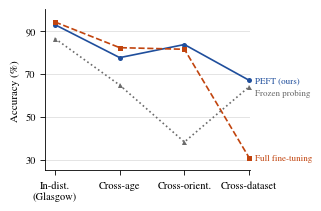

wrote paper_figure_shift_overview.pdf


In [9]:
# ── Figure: slope graph of accuracy in-distribution and under three shifts ──
# Values are loaded from the results JSONs (same helpers as Table 2), so the
# figure can never drift from the tables. One figure, IEEE single-column.
import matplotlib.pyplot as plt

IN_DIST_DS = "glasgow"      # leftmost point: "glasgow", "mad", or "mean"

def _indist(kind, key):
    g = in_dist_ft if kind == "ft" else in_dist_frozen
    if IN_DIST_DS == "mean":
        a, b = g(key, "glasgow"), g(key, "mad")
        return (a[0] + b[0]) / 2 * 100 if a and b else None
    r = g(key, IN_DIST_DS)
    return r[0] * 100 if r else None

def _shifts(kind, spec):
    out = []
    for _, (src, tgt) in CROSS_PAIRS.items():
        if kind == "peft":
            m, t = spec; r = cross_peft(m, t, src, tgt, SHOT); out.append(r[0]*100 if r else None)
        elif kind == "full_ft":
            r = cross_full_ft(src, tgt, SHOT); out.append(r[0]*100 if r else None)
        else:  # frozen
            v = cross_frozen(spec, src, tgt, SHOT); out.append(v*100 if v is not None else None)
    return out

REGIMES = ["In-dist.\n(Glasgow)", "Cross-age", "Cross-orient.", "Cross-dataset"]
# (label, in-dist spec, shift spec, color, linestyle, marker)
_SPEC = [
    # All three share the DINOv3-S backbone — only the adaptation strategy
    # varies, so the figure never conflates the two factors.
    ("PEFT (ours)",        ("ft","dinov3_vits16_pissa"),    ("peft",("pissa","all")), "#1f4e9c","-","o"),
    ("Full fine-tuning",   ("ft","dinov3_vits16_full_ft"),  ("full_ft",None),         "#c1440e","--","s"),
    ("Frozen probing",     ("frozen","dinov3_vits16"),      ("frozen","dinov3_vits16"),"#6b6b6b",":","^"),
]
DATA = {lab: ([_indist(*ind)] + _shifts(*sh), c, ls, mk)
        for lab, ind, sh, c, ls, mk in _SPEC}
for k,(v,*_) in DATA.items():
    print(f"{k:22s}", ["%.1f"%x if x is not None else "NA" for x in v])

# ---- style: IEEE single column, serif, grayscale/colorblind-safe encoding ----
plt.rcParams.update({
    "font.family":"serif", "font.serif":["Times New Roman","Nimbus Roman","DejaVu Serif"],
    "mathtext.fontset":"stix", "font.size":8, "axes.labelsize":8,
    "xtick.labelsize":7.5, "ytick.labelsize":7.5, "axes.linewidth":0.6,
    "xtick.major.width":0.6, "ytick.major.width":0.6, "lines.markersize":3.6,
    "pdf.fonttype":42, "ps.fonttype":42,
})
COL_W = 3.39
fig, ax = plt.subplots(figsize=(COL_W, 2.15))
x = range(len(REGIMES))

# de-overlap the direct end-labels (min vertical gap in data units)
ends = sorted(((v[-1], lab, c) for lab,(v,c,ls,mk) in DATA.items()), reverse=True)
lab_y, prev = {}, None
for yv, lab, c in ends:
    # Subtract 9.0 if the current label is too close to the one above it
    y = yv if prev is None or prev-yv >= 6.0 else prev-6.0
    lab_y[lab] = y; prev = y

for label,(vals,color,ls,marker) in DATA.items():
    ax.plot(x, vals, color=color, linestyle=ls, marker=marker,
            linewidth=1.2, markeredgewidth=0, zorder=3, clip_on=False)
    ax.annotate(label, xy=(len(REGIMES)-1, lab_y[label]), xytext=(4,0),
                textcoords="offset points", va="center", ha="left",
                fontsize=6.5, color=color)

ax.set_xticks(list(x)); ax.set_xticklabels(REGIMES)
ax.set_xlim(-0.15, len(REGIMES)-1+0.02)
ax.set_ylim(25, 100); ax.set_yticks([30,50,70,90])
ax.set_ylabel("Accuracy (%)")
ax.grid(axis="y", color="0.85", linewidth=0.5, zorder=0); ax.set_axisbelow(True)
for side in ("top","right"): ax.spines[side].set_visible(False)
fig.subplots_adjust(left=0.135, right=0.74, top=0.97, bottom=0.22)

fig.savefig("paper_figure_shift_overview.pdf")
fig.savefig("paper_figure_shift_overview_check.png", dpi=400)
plt.show()
print("wrote paper_figure_shift_overview.pdf")


## Table 4 — Controlled 2×2 adapter ablation (initialization × coverage)

Referenced in Sec. 4.3 as "a separate controlled 2×2 ablation, released with
the code". Table 3 varies initialization *and* coverage together (attention-only
LoRA → all-layer PiSSA); this table separates them on the DINOv3-S backbone,
under the cross-dataset shift:

|              | attention-only | all layers |
|--------------|----------------|------------|
| **LoRA init**  | reference      | coverage only |
| **PiSSA init** | init only      | our recipe |

Cells are produced by `scripts/run_ablation_2x2.sh`. Missing cells render as
`—`; run that script to fill them.


In [10]:
# Cross-dataset only — the shift scripts/run_ablation_2x2.sh covers. Append
# ("Cross-orient.", ("mad_sub12", "mad_sub3")) here (and re-enable it in that
# script) to extend Table 4 to the orientation shift too.
ABL2_PAIRS = [("Cross-dataset", ("glasgow_5", "mad_5"))]
ABL2_ROWS = [("LoRA (zero-B init)", "lora"), ("PiSSA (SVD init)", "pissa")]
ABL2_COLS = [("attn", "attention-only"), ("all", "all layers")]

def build_t4() -> pd.DataFrame:
    """Controlled 2x2: initialization x coverage, DINOv3-S backbone only."""
    records = []
    for row_label, method in ABL2_ROWS:
        row = {"": row_label}
        for pair_label, (src, tgt) in ABL2_PAIRS:
            for targets, cov_label in ABL2_COLS:
                key = cov_label if len(ABL2_PAIRS) == 1 else f"{pair_label}: {cov_label}"
                row[key] = fmt_pair(cross_peft(method, targets, src, tgt, SHOT))
        records.append(row)
    return pd.DataFrame(records)

T4 = build_t4()
display(Markdown(T4.to_markdown(index=False)))

_missing = int((T4 == "—").to_numpy().sum())
if _missing:
    display(Markdown(
        f"> **{_missing} cell(s) missing.** Run `bash scripts/run_ablation_2x2.sh` "
        "to generate them (requires fine-tuning; see README)."
    ))
T4


|                    | attention-only   | all layers   |
|:-------------------|:-----------------|:-------------|
| LoRA (zero-B init) | 65.54 (1.73)     | 64.87 (1.82) |
| PiSSA (SVD init)   | 62.73 (3.13)     | 66.92 (0.38) |

,,attention-only,all layers
0,LoRA (zero-B init),65.54 (1.73),64.87 (1.82)
1,PiSSA (SVD init),62.73 (3.13),66.92 (0.38)


## Macro-F1 companion tables

Sec. 3.1 states that macro-F1 was computed for every experiment and that it
preserved every ranking. Walking is over-represented after segmenting the 10 s
Glasgow clips, so accuracy alone could flatter methods that favour the majority
class. The cells below re-render every table above from the same JSONs with
`METRIC = "f1"`, and check the ranking claim programmatically.


In [11]:
# Re-render every table in macro-F1 by flipping the global metric switch.
METRIC = "f1"
T1_F1, T2_F1, T3_F1, T4_F1 = build_t1(), build_t2(), build_t3(), build_t4()
METRIC = "acc"          # restore, so later cells stay in accuracy

for _name, _df in [("Table 1 (macro-F1)", T1_F1), ("Table 2 (macro-F1)", T2_F1),
                   ("Table 3 (macro-F1)", T3_F1), ("Table 4 (macro-F1)", T4_F1)]:
    display(Markdown(f"**{_name}**"))
    display(Markdown(_df.to_markdown(index=False)))


**Table 1 (macro-F1)**

| Method                  | Trainable         | Total    | Glasgow      | MAD          |
|:------------------------|:------------------|:---------|:-------------|:-------------|
| *Small (~22-25M total)* |                   |          |              |              |
| ViT-S ImageNet (frozen) | ~0 M (probe only) | 21.67 M  | 85.91 (1.39) | 63.05 (1.64) |
| DINOv3-S (frozen)       | ~0 M (probe only) | 21.60 M  | 84.90 (1.73) | 72.85 (0.97) |
| ResNet50 (ft)           | 23.52 M (100.00%) | 23.52 M  | 94.07 (1.16) | 97.93 (0.60) |
| DINOv3-S (full FT)      | 21.60 M (100.00%) | 21.60 M  | 93.38 (0.79) | 97.82 (0.64) |
| SelaFD ViT-S            | 3.63 M (14.35%)   | 25.29 M  | 89.68 (1.21) | 95.87 (0.59) |
| ViT-S + LoRA            | 223 K (1.02%)     | 21.89 M  | 91.01 (1.24) | 93.91 (0.69) |
| DINOv3-S + PiSSA (Ours) | 666 K (2.99%)     | 22.26 M  | 92.08 (1.58) | 97.38 (0.49) |
| *Base (~86-100M total)* |                   |          |              |              |
| ViT-B ImageNet (frozen) | ~0 M (probe only) | 85.80 M  | 86.86 (2.25) | 67.02 (2.23) |
| DINOv3-B (frozen)       | ~0 M (probe only) | 85.66 M  | 85.82 (1.44) | 74.24 (1.13) |
| SelaFD ViT-B            | 14.34 M (14.32%)  | 100.13 M | 91.10 (0.90) | 96.74 (0.76) |
| DINOv3-B + PiSSA (Ours) | 1.33 M (1.53%)    | 86.99 M  | 93.24 (1.18) | 97.61 (0.52) |

**Table 2 (macro-F1)**

| Method                      | Cross-age    | Cross-orientation   | Cross-Dataset   |
|:----------------------------|:-------------|:--------------------|:----------------|
| DINOv3 ViT-S (frozen)       | 59.60        | 38.36               | 61.43           |
| ViT-S ImageNet (frozen)     | 63.35        | 29.11               | 52.20           |
| ResNet50 (full FT)          | 76.43 (0.48) | 79.25 (1.66)        | 30.36 (3.00)    |
| DINOv3 ViT-S (full FT)      | 79.85 (0.74) | 81.19 (0.65)        | 28.90 (2.80)    |
| SelaFD (ViT-S ImageNet)     | 72.55 (0.96) | 76.69 (0.24)        | 55.10 (0.81)    |
| ImageNet ViT-S + LoRA       | 74.08 (0.62) | 75.53 (0.87)        | 54.24 (1.00)    |
| DINOv3 ViT-S + PiSSA (Ours) | 75.19 (0.28) | 83.35 (1.04)        | 64.39 (0.57)    |

**Table 3 (macro-F1)**

|             | Cross-orient.: ImageNet ViT-S   | Cross-orient.: DINOv3 ViT-S   | Cross-dataset: ImageNet ViT-S   | Cross-dataset: DINOv3 ViT-S   |
|:------------|:--------------------------------|:------------------------------|:--------------------------------|:------------------------------|
| LoRA (attn) | 75.53 (0.87)                    | 80.26 (1.06)                  | 54.24 (1.00)                    | 63.15 (1.80)                  |
| PiSSA (all) | 80.98 (1.52)                    | 83.35 (1.04)                  | 55.28 (1.13)                    | 64.39 (0.57)                  |

**Table 4 (macro-F1)**

|                    | attention-only   | all layers   |
|:-------------------|:-----------------|:-------------|
| LoRA (zero-B init) | 63.15 (1.80)     | 62.27 (1.86) |
| PiSSA (SVD init)   | 59.79 (3.32)     | 64.39 (0.57) |

In [12]:
# Verify the paper's claim: macro-F1 preserves every ranking, mean gap ~1.3 pp.
def _ranking_check() -> pd.DataFrame:
    """Compare accuracy and macro-F1 orderings cell-column by cell-column."""
    global METRIC
    rows, gaps = [], []

    def _collect(metric: str) -> dict[str, dict[str, float]]:
        global METRIC
        METRIC = metric
        out: dict[str, dict[str, float]] = {}
        for ds in ("glasgow", "mad"):
            col = {}
            for label, key, kind in T1_ROWS:
                if kind == "hdr":
                    continue
                v = in_dist_ft(key, ds) if kind == "ft" else in_dist_frozen(key, ds)
                if v:
                    col[label] = v[0]
            out[f"Table 1 / {ds}"] = col
        for cname, (src, tgt) in CROSS_PAIRS.items():
            col = {}
            for label, kind, spec in T2_ROWS:
                if kind == "frozen":
                    v = cross_frozen(spec, src, tgt, SHOT)
                elif kind == "resnet":
                    r = cross_resnet(src, tgt, SHOT);  v = r[0] if r else None
                elif kind == "full_ft":
                    r = cross_full_ft(src, tgt, SHOT); v = r[0] if r else None
                elif kind == "selafd":
                    r = cross_selafd(src, tgt, SHOT);  v = r[0] if r else None
                else:
                    r = cross_peft(*spec, src, tgt, SHOT); v = r[0] if r else None
                if v is not None:
                    col[label] = v
            out[f"Table 2 / {cname}"] = col
        return out

    acc, f1 = _collect("acc"), _collect("f1")
    METRIC = "acc"
    for col in acc:
        keys = [k for k in acc[col] if k in f1[col]]
        order_a = sorted(keys, key=lambda k: -acc[col][k])
        order_f = sorted(keys, key=lambda k: -f1[col][k])
        gap = np.mean([(acc[col][k] - f1[col][k]) * 100 for k in keys])
        gaps.extend([(acc[col][k] - f1[col][k]) * 100 for k in keys])
        rows.append({"Column": col, "n rows": len(keys),
                     "Ranking": "preserved" if order_a == order_f else "CHANGED",
                     "mean acc − F1 (pp)": f"{gap:.2f}"})
    df = pd.DataFrame(rows)
    display(Markdown(df.to_markdown(index=False)))
    display(Markdown(f"**Overall mean accuracy − macro-F1 gap: "
                     f"{np.mean(gaps):.2f} pp** over {len(gaps)} cells."))
    return df

_ = _ranking_check()


| Column                      |   n rows | Ranking   |   mean acc − F1 (pp) |
|:----------------------------|---------:|:----------|---------------------:|
| Table 1 / glasgow           |       11 | preserved |                 0.99 |
| Table 1 / mad               |       11 | preserved |                 0.22 |
| Table 2 / Cross-age         |        7 | preserved |                 3.02 |
| Table 2 / Cross-orientation |        7 | preserved |                 0.16 |
| Table 2 / Cross-Dataset     |        7 | preserved |                 2.68 |

**Overall mean accuracy − macro-F1 gap: 1.26 pp** over 43 cells.

## Zero-shot transfer (no target labels at all)

Footnote 1 of Sec. 3.2: the source-trained classification head is applied
directly to the target, with no target-side probe refit. This is strictly
harder than Table 2's 10-shot protocol. Only methods that have a source-trained
head appear (frozen probes have none). Produced by `scripts/run_zero_shot.py`.


In [13]:
ZERO_SHOT_DIR = REPO_ROOT / "results" / "zero_shot"
ZS_SHIFTS = ["cross-age", "cross-orientation", "cross-dataset"]

def build_zero_shot(metric: str = "acc") -> pd.DataFrame:
    """One row per method, one column per shift: mean (std) over 3 seeds."""
    acc: dict[tuple[str, str], list[float]] = defaultdict(list)
    for fp in sorted(ZERO_SHOT_DIR.glob("*.json")):
        d = json.loads(fp.read_text())
        sv = d.get("probes", {}).get("supervised")
        if sv is None or metric not in sv or d["shift"] not in ZS_SHIFTS:
            continue
        acc[(d["method_label"], d["shift"])].append(sv[metric] * 100)

    records = []
    for lab in sorted({k[0] for k in acc}):
        row = {"Method": lab}
        for shift in ZS_SHIFTS:
            vs = acc.get((lab, shift), [])
            row[shift] = "—" if not vs else f"{np.mean(vs):.2f} ({np.std(vs):.2f})"
        records.append(row)
    return pd.DataFrame(records)

ZS = build_zero_shot("acc")
display(Markdown(ZS.to_markdown(index=False)))
display(Markdown(
    "Reference points: the cross-dataset target (MAD, 5 shared classes) has a "
    "**29.40%** majority class, so every method there scores at or below simply "
    "predicting the most frequent activity. Best cross-orientation zero-shot is "
    "47.18%, against 83.56% for the best method at 10-shot (Table 2)."
))
ZS


| Method                  | cross-age    | cross-orientation   | cross-dataset   |
|:------------------------|:-------------|:--------------------|:----------------|
| DINOv3-S (full FT)      | 79.13 (2.33) | 39.85 (1.45)        | 24.01 (4.50)    |
| DINOv3-S + PiSSA (Ours) | 70.36 (2.14) | 44.07 (0.23)        | 25.25 (2.36)    |
| ImageNet ViT-S + LoRA   | 69.10 (2.16) | 44.84 (0.60)        | 15.54 (3.07)    |
| ResNet50 (full FT)      | 75.33 (1.67) | 47.18 (3.46)        | 25.46 (5.58)    |
| SelaFD-S                | 68.73 (0.75) | 43.44 (2.10)        | 21.88 (1.67)    |

Reference points: the cross-dataset target (MAD, 5 shared classes) has a **29.40%** majority class, so every method there scores at or below simply predicting the most frequent activity. Best cross-orientation zero-shot is 47.18%, against 83.56% for the best method at 10-shot (Table 2).

,Method,cross-age,cross-orientation,cross-dataset
0,DINOv3-S (full FT),79.13 (2.33),39.85 (1.45),24.01 (4.50)
1,DINOv3-S + PiSSA (Ours),70.36 (2.14),44.07 (0.23),25.25 (2.36)
2,ImageNet ViT-S + LoRA,69.10 (2.16),44.84 (0.60),15.54 (3.07)
3,ResNet50 (full FT),75.33 (1.67),47.18 (3.46),25.46 (5.58)
4,SelaFD-S,68.73 (0.75),43.44 (2.10),21.88 (1.67)


## (Optional) LaTeX export for paper inclusion

Run the cell below to dump each table to LaTeX `tabular` form.

In [14]:
for name, df in [("T1 in-distribution",            T1),
                 ("T2 cross-dist (10-shot)",       T2),
                 ("T3 ablation (backbone x recipe)", T3),
                 ("T4 controlled 2x2 (init x coverage)", T4),
                 ("T1 macro-F1",                   T1_F1),
                 ("T2 macro-F1",                   T2_F1),
                 ("T3 macro-F1",                   T3_F1),
                 ("T4 macro-F1",                   T4_F1),
                 ("Zero-shot transfer",            ZS)]:
    print(f"% \u2500\u2500 {name} \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500")
    print(df.to_latex(index=False, escape=False))
    print()


% ── T1 in-distribution ─────────────
\begin{tabular}{lllll}
\toprule
Method & Trainable & Total & Glasgow & MAD \\
\midrule
*Small (~22-25M total)* &  &  &  &  \\
ViT-S ImageNet (frozen) & ~0 M (probe only) & 21.67 M & 87.16 (1.58) & 63.51 (1.24) \\
DINOv3-S (frozen) & ~0 M (probe only) & 21.60 M & 86.35 (1.52) & 73.34 (1.00) \\
ResNet50 (ft) & 23.52 M (100.00%) & 23.52 M & 94.57 (1.08) & 97.94 (0.59) \\
DINOv3-S (full FT) & 21.60 M (100.00%) & 21.60 M & 94.04 (0.78) & 97.86 (0.61) \\
SelaFD ViT-S & 3.63 M (14.35%) & 25.29 M & 90.77 (1.19) & 95.96 (0.66) \\
ViT-S + LoRA & 223 K (1.02%) & 21.89 M & 91.92 (1.20) & 94.14 (0.73) \\
DINOv3-S + PiSSA (Ours) & 666 K (2.99%) & 22.26 M & 92.79 (1.37) & 97.43 (0.47) \\
*Base (~86-100M total)* &  &  &  &  \\
ViT-B ImageNet (frozen) & ~0 M (probe only) & 85.80 M & 88.26 (2.03) & 67.36 (1.88) \\
DINOv3-B (frozen) & ~0 M (probe only) & 85.66 M & 87.12 (1.28) & 74.83 (0.93) \\
SelaFD ViT-B & 14.34 M (14.32%) & 100.13 M & 92.06 (0.72) & 96.82 (0.73) 